Logs   
- [2025/01/28]    
  This is a copy from `/program-gao-2021-ga-numba/datasets/generate_datasets.ipynb`.   
  Data is created using `seed=250128`. Different seed will produce different 
  data.

- [2025/08/02]   
  There is a mistake in the creation of processing time, I mistakenly used
  twice the variable `idx` inside the nested loop such that it will overwrite
  the `idx` of the outer loop. If you run this notebook, please
  make sure to store first the previous generated datasets of 100 instances.


In [1]:
import numpy as np
import networkx as nx
import math
import pandas as pd

import matplotlib.pyplot as plt

In [2]:
plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams.update({
  'font.size': 16,
  'grid.alpha': 0.25})

In [3]:
def generate_random_directed_tree(n, idx_start=0, rng=None):
  """
  Generates a directed tree with a single root node, total of `n` nodes,
  and depth `d` randomly chosen between 2 and ceil(n/2) inclusive.
  """
  if n < 2:
    raise ValueError("The total number of nodes 'n' must be at least 2.")

  # Step 1: Randomly select depth 'd' between 2 and ceil(n/2) inclusive
  d_min = 2
  d_max = (n + 1) // 2  # ceil(n/2)
  d = rng.integers(d_min, d_max, endpoint=True)
  print(f"Selected depth (number of layers): {d}")

  # Step 2: Generate a random composition of n - 1 nodes into d - 1 layers
  sizes = random_composition(n - 1, d - 1)
  print(f"Nodes per layer (excluding root): {sizes}")

  # Step 3: Initialize the directed graph and add the root node
  G = nx.DiGraph()
  node_id = idx_start
  G.add_node(node_id)
  layers = {0: [node_id]}  # Layer 0 contains the root node
  node_id += 1

  # Step 4: Build the tree layer by layer
  for layer in range(1, d):
    layer_size = sizes[layer - 1]
    layers[layer] = []
    for _ in range(layer_size):
      G.add_node(node_id)
      # Randomly select a parent from the previous layer
      # parent = random.choice(layers[layer - 1])
      parent = rng.choice(layers[layer - 1])
      G.add_edge(parent, node_id)  # Edge from parent to child
      layers[layer].append(node_id)
      node_id += 1

  # Verify the total number of nodes
  assert G.number_of_nodes() == n, "The total number of nodes does not match 'n'."

  return G


def random_composition(n, k):
  """
  Generates a random composition of integer 'n' into 'k' positive integers.
  """
  if k <= 0 or n <= 0:
    raise ValueError("Both 'n' and 'k' must be positive integers.")
  if k > n:
    raise ValueError("'k' cannot be greater than 'n'.")

  # Randomly place k - 1 dividers between 1 and n - 1
  # dividers = sorted(random.sample(range(1, n), k - 1))
  dividers = sorted(rng.choice(range(1, n), k - 1, replace=False))
  # The sizes are the differences between the dividers
  sizes = [a - b for a, b in zip(dividers + [n], [0] + dividers)]
  return sizes

In [4]:
def write_process_priority(filename, tree):
  # Create a dictionary to store the parent-child relationships
  tree_dict = {}

  # Traverse the graph to get the children for each node
  for parent in tree.nodes:
    children = list(tree.successors(parent))  # Get the children of the node
    # print(children)
    if children:  # Only add parent nodes that have children
      tree_dict[f"W{parent}"] = ','.join([f"W{str(node)}" for node in children])

  tree_df = pd.DataFrame(list(tree_dict.items()), columns=["parent", "children"])
  tree_df.to_csv(filename, index=False)

  return None

Selected depth (number of layers): 31
Nodes per layer (excluding root): [1, 4, 3, 1, 5, 1, 2, 3, 1, 7, 1, 1, 4, 1, 2, 1, 2, 5, 2, 2, 1, 6, 3, 4, 1, 2, 3, 6, 3, 3]


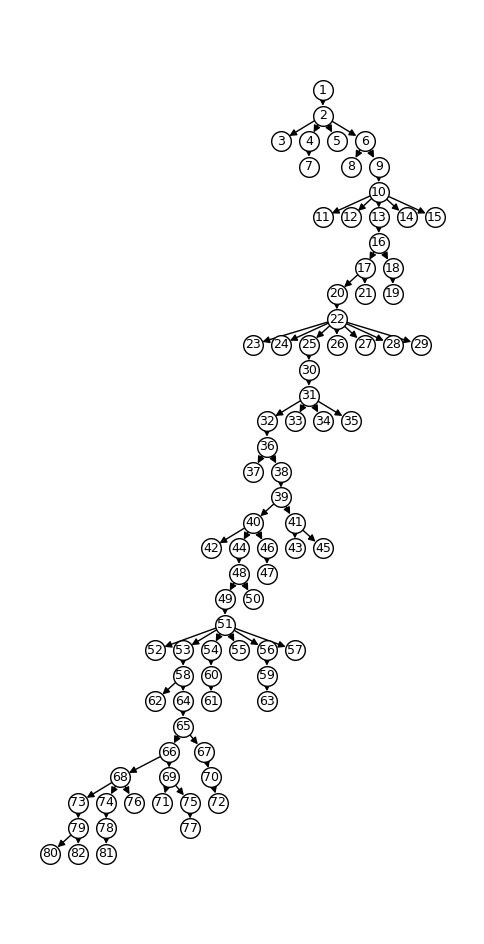

Write to .csv


In [29]:
num_of_op = 82
# num_of_op = 21 
# seed = 241018
seed = 25018
rng = np.random.default_rng(seed)
filename = f"./process-priority-{num_of_op}.csv"

# Generate a tree with 82 nodes
tree = generate_random_directed_tree(num_of_op, idx_start=1, rng=rng)

fig, ax = plt.subplots(figsize=(6, 12))
pos = nx.drawing.nx_agraph.graphviz_layout(tree, prog='dot', 
  args='-Grankdir=TB')
nx.draw(tree, pos, with_labels=True, ax=ax, arrows=True, node_color="w",
        edgecolors="k", node_size=200, font_size=9)
plt.show(fig)

print("Write to .csv")
write_process_priority(filename, tree)

Generate processing machine time

`process-machine-time-N-M.csv`

| op  | p1 | p2 | p3 | ... | pM |
|-----|----|----|----|-----|----|
| W1  | p_11 | p_12 | p_13 | ... | p_1M |
| W2  | p_21 | p_22 | p_33 | ... | p_2M |
| W3  | p_31 | p_32 | p_33 | ... | p_3M |
| ... | ...  | ...  | ...  | ... | ... |
| WN  | p_N1 | p_N2 | p_N3 | ... | p_NM |

N is the number of operations   
M is the number of machines

Our assumption for generating this `process-machine-time` is that
all operations are flexible over machines.   
No operation can be operated only in a single machine.

In [47]:
range_processing_time = [1, 20]  # (Gao et al., 2021) - flexible machine fixed factory
range_num_of_machine = [4, 8]    # (Gao et al., 2021) - flexible machine fixed factory
min_available_machine = 2


# seed = 241018
seed = 250128
# seed = None
rng = np.random.default_rng(seed)

num_of_machine = rng.integers(*range_num_of_machine, endpoint=True)
print(f"num_of_machine", num_of_machine)

p_ik = np.zeros((num_of_op, num_of_machine), dtype=np.int32)
num_of_available_machines_arr = np.zeros(num_of_op, dtype=np.int32)
dict_available_machine = {}

for idx in range(num_of_op):
  # -- sample available machine for each operation
  num_of_available_machines = rng.integers(min_available_machine, num_of_machine, endpoint=True)
  idx_available_machine = rng.choice(
    np.arange(num_of_machine, dtype=np.int32), 
    size=num_of_available_machines, replace=False)   # zero based index
  idx_available_machine = sorted(idx_available_machine)
  
  # -- for printing the variables
  num_of_available_machines_arr[idx] = num_of_available_machines
  dict_available_machine[idx] = idx_available_machine

  # -- processing time for each available machines
  p_ik[idx, idx_available_machine] \
    = rng.integers(*range_processing_time, num_of_available_machines, endpoint=True)
  # print(num_of_available_machines, idx_available_machine, p_ik)

# -- printing
# for idx, p_i in enumerate(p_ik):
#   # -- 3 is for number, comma and space
#   # -- -2 is for missing comma and space for the last element
#   # -- +2 is for the brackets
#   additional_space = (num_of_machine * 3 - 2) + 2 - len(f"{dict_available_machine[idx]}")
#   print(num_of_available_machines_arr[idx],
#         dict_available_machine[idx], " "*additional_space, p_ik[idx])
  

filename_processing_time = f"./process-machine-time-{num_of_op}-{num_of_machine}.csv"
df_processing_time = pd.DataFrame()
df_processing_time["op"] = [f"W{node+1}" for node in range(num_of_op)]
for idx in range(num_of_machine):
  df_processing_time[f"p{idx+1}"] = p_ik[:, idx]
display(df_processing_time)

print(f"Write processing time to .csv")
df_processing_time.to_csv(filename_processing_time, index=False)

num_of_machine 5


,op,p1,p2,p3,p4,p5
0,W1,7,0,0,2,3
1,W2,3,10,18,2,19
2,W3,0,0,1,19,0
3,W4,0,2,13,0,5
4,W5,0,0,9,0,16
...,...,...,...,...,...,...
77,W78,0,1,14,0,0
78,W79,0,1,0,6,0
79,W80,7,0,0,0,16
80,W81,0,15,15,3,6


Write processing time to .csv


Generate `factory-transfer-time`

`factory-transfer-time-F`

| start_fac | end_fac | time |
|-----------|---------|------|
| $2$         | $1$       | $D(f_2,f_1)$ | 
| $3$         | $1$       | $D(f_3,f_1)$ |
| $3$         | $2$       | $D(f_3,f_2)$ |
| $4$         | $1$       | $D(f_4,f_1)$ |
| $4$         | $2$       | $D(f_4,f_2)$ |
| $4$         | $3$       | $D(f_4,f_3)$ |
| ...       | ...     | ...    |
| $F$         | $F-3$     | $D(f_F, f_{F-3})$ |
| $F$         | $F-2$     | $D(f_F, f_{F-2})$ |
| $F$         | $F-1$     | $D(f_F, f_{F-1})$ |

In [58]:
range_number_of_factory = [2, 5]
range_D_fifj = [1, 4]   # our assumption

seed = 250128
# seed = None
rng = np.random.default_rng(seed)

num_of_factory = rng.integers(*range_num_of_machine, endpoint=True)
print(f"num_of_factory:", num_of_factory)

factory_transfer_time = []
for start_fac in range(2, num_of_factory+1):
  for end_fac in range(1, start_fac):
    D_fifj = rng.integers(*range_D_fifj, endpoint=True)
    # print(start_fac, end_fac, D_fifj)
    factory_transfer_time.append([start_fac, end_fac, D_fifj])

filename_transfer_time = f"./factory-transfer-time-{num_of_op}-{num_of_machine}-{num_of_factory}.csv"

df_factory_transfer_time = pd.DataFrame()
factory_transfer_time = np.array(factory_transfer_time)
df_factory_transfer_time["start_fac"] = factory_transfer_time[:, 0]
df_factory_transfer_time["end_fac"] = factory_transfer_time[:, 1]
df_factory_transfer_time["D_fifj"] = factory_transfer_time[:, 2]

df_factory_transfer_time

print(f"Write factory transfer time to .csv")
df_factory_transfer_time.to_csv(filename_transfer_time, index=False)


num_of_factory: 5
Write factory transfer time to .csv


### Generate 100 instances

In [ ]:
# seed = 241104
seed = 250128
rng = np.random.default_rng(seed)

num_of_instances = 100
range_num_of_op = [50, 100]
range_num_of_machines = [4, 8]
range_processing_time = [1, 20]
range_number_of_factory = [2, 5]
range_D_fifj = [1, 4]   # our assumption
min_available_machine = 2

directory = "./one-hundred-instances-flexible/"

for instance in range(num_of_instances):
  print(f"Instance: {instance:03d}")
  num_of_op = rng.integers(*range_num_of_op, endpoint=True)
  num_of_machine = rng.integers(*range_num_of_machines, endpoint=True)
  num_of_factory = rng.integers(*range_number_of_factory, endpoint=True)
  
  # -- create process-priority
  filename = f"./{instance:03d}-process-priority-{num_of_op}.csv"

  tree = generate_random_directed_tree(num_of_op, idx_start=1, rng=rng)

  print("  Write process priority to .csv")
  write_process_priority(directory+filename, tree)


  # -- create process-machine-time data
  p_ik = np.zeros((num_of_op, num_of_machine), dtype=np.int32)

  for idx in range(num_of_op):
    # -- sample available machine for each operation
    num_of_available_machines = rng.integers(min_available_machine, num_of_machine, endpoint=True)
    idx_available_machine = rng.choice(
      np.arange(num_of_machine, dtype=np.int32), 
      size=num_of_available_machines, replace=False)   # zero based index
    idx_available_machine = sorted(idx_available_machine)
    
    # -- processing time for each available machines
    p_ik[idx, idx_available_machine] \
      = rng.integers(*range_processing_time, num_of_available_machines, endpoint=True)
    # print(num_of_available_machines, idx_available_machine, p_ik)

  filename_processing_time = f"./{instance:03d}-process-machine-time-{num_of_op}-{num_of_machine}.csv"
  df_processing_time = pd.DataFrame()
  df_processing_time["op"] = [f"W{node+1}" for node in range(num_of_op)]
  for idx_j in range(num_of_machine):
    df_processing_time[f"p{idx_j+1}"] = p_ik[:, idx_j]

  print(f"  Write processing time to .csv")
  df_processing_time.to_csv(directory+filename_processing_time, index=False)


  # -- create factory-transfer-time data
  filename_transfer_time = f"./{instance:03d}-factory-transfer-time-"\
    + f"{num_of_op}-{num_of_machine}-{num_of_factory}.csv"

  factory_transfer_time = []
  for start_fac in range(2, num_of_factory+1):
    for end_fac in range(1, start_fac):
      D_fifj = rng.integers(*range_D_fifj, endpoint=True)
      factory_transfer_time.append([start_fac, end_fac, D_fifj])


  df_factory_transfer_time = pd.DataFrame()
  factory_transfer_time = np.array(factory_transfer_time)
  df_factory_transfer_time["start_fac"] = factory_transfer_time[:, 0]
  df_factory_transfer_time["end_fac"] = factory_transfer_time[:, 1]
  df_factory_transfer_time["D_fifj"] = factory_transfer_time[:, 2]

  print(f"  Write factory transfer time to .csv")
  df_factory_transfer_time.to_csv(directory+filename_transfer_time, index=False)

Instance: 000
Selected depth (number of layers): 9
Nodes per layer (excluding root): [4, 3, 11, 1, 20, 10, 7, 5]
  Write process priority to .csv
  Write processing time to .csv
  Write factory transfer time to .csv
Instance: 001
Selected depth (number of layers): 24
Nodes per layer (excluding root): [1, 5, 1, 3, 2, 2, 3, 6, 1, 4, 2, 2, 2, 1, 2, 1, 2, 2, 1, 1, 1, 3, 2]
  Write process priority to .csv
  Write processing time to .csv
  Write factory transfer time to .csv
Instance: 002
Selected depth (number of layers): 6
Nodes per layer (excluding root): [18, 17, 13, 3, 14]
  Write process priority to .csv
  Write processing time to .csv
  Write factory transfer time to .csv
Instance: 003
Selected depth (number of layers): 5
Nodes per layer (excluding root): [17, 1, 24, 28]
  Write process priority to .csv
  Write processing time to .csv
  Write factory transfer time to .csv
Instance: 004
Selected depth (number of layers): 5
Nodes per layer (excluding root): [27, 24, 22, 16]
  Write pro